# %% [markdown]
# # Notebook 03 — Model Training
# ## Reply Sandbox 2026 Challenge
#
# ### Goals
# - Load the feature matrix built in notebook 02 (`features_lev1.csv`)
# - Train multiple classifiers to predict **preventive support** (label = 1)
# - Handle class imbalance (4:1 ratio) via model-level weighting
# - Evaluate using **F1 Score** as the primary metric
# - Use **LeaveOneGroupOut** cross-validation grouped by CitizenID to simulate
#   realistic deployment: the model must generalise to *unseen citizens*, not
#   just unseen rows from citizens it has already learned from.
# - Save the best model and diagnostic figures for downstream use.

In [4]:
# =============================================================================
# Cell 1 — Imports & Config
# =============================================================================
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, classification_report
from xgboost import XGBClassifier
import joblib

warnings.filterwarnings("ignore")

# ── Fix working directory ─────────────────────────────────────────────────────
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(BASE_DIR)
print(f"✅ Working directory: {BASE_DIR}")

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH = BASE_DIR / "data/processed/features_lev1.csv"
MODEL_PATH = BASE_DIR / "models/xgb_lev1.pkl"
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f"{'✅' if DATA_PATH.exists() else '❌'} {DATA_PATH}")

✅ Working directory: c:\Progetti\Reply-sandbox-2026-the-eye
✅ c:\Progetti\Reply-sandbox-2026-the-eye\data\processed\features_lev1.csv


In [ ]:
# %% [markdown]
# ## 2. Load Feature Matrix

# %%

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print(f"\nLabel distribution:\n{df['label'].value_counts().to_string()}")
print(f"\nCitizens      : {df['CitizenID'].unique()}")
print(f"Positive rate : {df['label'].mean():.2%}")

# %%
# Separate features, target, and groups
# Drop non-feature columns; 'CitizenID' is kept separately as the CV group key
NON_FEATURE_COLS = ["label", "CitizenID"]

X = df.drop(columns=NON_FEATURE_COLS)
y = df["label"]
groups = df["CitizenID"]  # used by LeaveOneGroupOut

print(f"\nFeature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}  (positives={y.sum()}, negatives={(y==0).sum()})")

Dataset shape : (50, 47)
Columns       : ['CitizenID', 'PhysicalActivityIndex', 'SleepQualityIndex', 'EnvironmentalExposureLevel', 'label', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_night', 'PhysicalActivityIndex_roll3_mean', 'PhysicalActivityIndex_roll3_std', 'SleepQualityIndex_roll3_mean', 'SleepQualityIndex_roll3_std', 'EnvironmentalExposureLevel_roll3_mean', 'EnvironmentalExposureLevel_roll3_std', 'PhysicalActivityIndex_lag1', 'PhysicalActivityIndex_lag2', 'SleepQualityIndex_lag1', 'SleepQualityIndex_lag2', 'EnvironmentalExposureLevel_lag1', 'EnvironmentalExposureLevel_lag2', 'event_follow-up assessment', 'event_lifestyle coaching session', 'event_preventive screening', 'event_routine check-up', 'event_specialist consultation', 'geo_event_count', 'geo_mean_lat', 'geo_mean_lng', 'geo_std_lat', 'geo_std_lng', 'geo_mean_dist_centroid', 'geo_max_dist_centroid', 'geo_unique_cities', 'PhysicalActivityIndex_agg_mean', 'PhysicalActivityIndex_agg_std', 'PhysicalActivityIndex_agg_min

In [6]:
# %% [markdown]
# ## 3. Cross-Validation Strategy — LeaveOneGroupOut
#
# ### Why not a random train/test split?
#
# A simple random split would let the model train on rows from **all** citizens,
# including Craig Connor (WNACROYX), then test on different rows from the same
# citizens. Because citizen behaviour is temporally correlated, the model would
# appear artificially accurate — it has effectively *seen* every citizen at
# train time.
#
# **LeaveOneGroupOut (LOGO)** creates 5 folds, each time holding out **all**
# records of a single citizen as the test set. This mimics production: the
# model must predict for a citizen it has never encountered during training,
# which is the only honest estimate of generalisation on new citizens.

# %%
logo = LeaveOneGroupOut()

print("LOGO fold summary:")
print(f"  Number of folds : {logo.get_n_splits(X, y, groups)}")
for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    test_citizen = groups.iloc[test_idx].unique()[0]
    pos_in_test  = y.iloc[test_idx].sum()
    print(
        f"  Fold {fold_idx+1}: test citizen = {test_citizen:>10s} | "
        f"test rows = {len(test_idx):>4d} | positives = {pos_in_test}"
    )

LOGO fold summary:
  Number of folds : 5
  Fold 1: test citizen =   DCGGXUWF | test rows =   10 | positives = 0
  Fold 2: test citizen =   IAFGUHCK | test rows =   10 | positives = 0
  Fold 3: test citizen =   IXTDRHTR | test rows =   10 | positives = 0
  Fold 4: test citizen =   RFLFWVQA | test rows =   10 | positives = 0
  Fold 5: test citizen =   WNACROYX | test rows =   10 | positives = 3


In [7]:
# %% [markdown]
# ## 4. Model Definitions
#
# All three models receive explicit instructions to counteract the 4:1 class
# imbalance so minority-class recall is not sacrificed for overall accuracy.

# %%
# ------------------------------------------------------------------
# XGBoost  — scale_pos_weight compensates imbalance directly
# ------------------------------------------------------------------
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=4,          # ratio negative/positive ≈ 4
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    verbosity=0,
)

# ------------------------------------------------------------------
# LightGBM — class_weight='balanced' re-weights internally
# ------------------------------------------------------------------
lgbm_model = LGBMClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    class_weight="balanced",
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbose=-1,
)

# ------------------------------------------------------------------
# Random Forest — class_weight='balanced' re-weights internally
# ------------------------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight="balanced",
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

MODELS = {
    "XGBoost":       xgb_model,
    "LightGBM":      lgbm_model,
    "RandomForest":  rf_model,
}

In [12]:
# =============================================================================
# Cell 5 — Training semplificato per dataset piccolo (Livello 1)
# =============================================================================
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report

# ── Prepara features e label ──────────────────────────────────────────────────
DROP_COLS = ["label", "CitizenID"]
feature_cols = [c for c in df.columns if c not in DROP_COLS]

X = df[feature_cols].select_dtypes(include=[np.number])
y = df["label"]

print(f"Features: {X.shape[1]} | Samples: {X.shape[0]}")
print(f"Label distribution:\n{y.value_counts()}")

# ── Leave-One-Citizen-Out cross validation ────────────────────────────────────
# Con 5 cittadini, usiamo ogni cittadino come test set a turno
citizens = df["CitizenID"].unique()
print(f"\nCittadini: {citizens}")

results = []
for test_citizen in citizens:
    mask_test = df["CitizenID"] == test_citizen
    X_train = X[~mask_test]
    X_test = X[mask_test]
    y_train = y[~mask_test]
    y_test = y[mask_test]

    # Salta se il test set non ha positivi
    if y_test.sum() == 0:
        continue

    # XGBoost con scale_pos_weight
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    scale = n_neg / n_pos if n_pos > 0 else 1

    clf = XGBClassifier(
        n_estimators=100,
        scale_pos_weight=scale,
        random_state=42,
        verbosity=0,
        eval_metric="logloss",
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    results.append({"citizen": test_citizen, "f1": f1})
    print(f"\nTest citizen: {test_citizen}")
    print(classification_report(y_test, y_pred, zero_division=0))

# ── Train finale su tutti i dati ──────────────────────────────────────────────
print("\n🔁 Training finale su tutto il dataset...")
clf_final = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=4,
    random_state=42,
    verbosity=0,
    eval_metric="logloss",
)
clf_final.fit(X, y)

import joblib
joblib.dump(clf_final, MODEL_PATH)
print(f"✅ Modello salvato in: {MODEL_PATH}")
print(f"\nFeature importance (top 10):")
importances = pd.Series(clf_final.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(10))

Features: 45 | Samples: 50
Label distribution:
label
0    47
1     3
Name: count, dtype: int64

Cittadini: <StringArray>
['DCGGXUWF', 'IAFGUHCK', 'IXTDRHTR', 'RFLFWVQA', 'WNACROYX']
Length: 5, dtype: str

Test citizen: WNACROYX
              precision    recall  f1-score   support

           0       0.70      1.00      0.82         7
           1       0.00      0.00      0.00         3

    accuracy                           0.70        10
   macro avg       0.35      0.50      0.41        10
weighted avg       0.49      0.70      0.58        10


🔁 Training finale su tutto il dataset...
✅ Modello salvato in: c:\Progetti\Reply-sandbox-2026-the-eye\models\xgb_lev1.pkl

Feature importance (top 10):
event_follow-up assessment               0.905254
EnvironmentalExposureLevel_roll3_mean    0.094746
SleepQualityIndex                        0.000000
hour                                     0.000000
EnvironmentalExposureLevel               0.000000
day_of_week                              0

In [13]:
# %% [markdown]
# ## 6. Results Table

# %%
summary_rows = []
for name, res in results.items():
    agg = res["aggregate"]
    summary_rows.append({
        "Model":     name,
        "F1 Score":  round(agg["F1"], 4),
        "Precision": round(agg["Precision"], 4),
        "Recall":    round(agg["Recall"], 4),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("F1 Score", ascending=False).reset_index(drop=True)
print("\n===== Model Comparison (LeaveOneGroupOut, aggregated) =====")
print(summary_df.to_string(index=False))

# Per-fold breakdown
print("\n===== Per-fold F1 by Citizen =====")
for name, res in results.items():
    print(f"\n{name}:")
    fold_df = pd.DataFrame(res["fold_results"])[["citizen", "f1", "precision", "recall"]]
    print(fold_df.to_string(index=False))

AttributeError: 'list' object has no attribute 'items'

Best model: XGBoost  (F1=0.0000)


FileNotFoundError: [Errno 2] No such file or directory: 'figures/10_feature_importance.png'

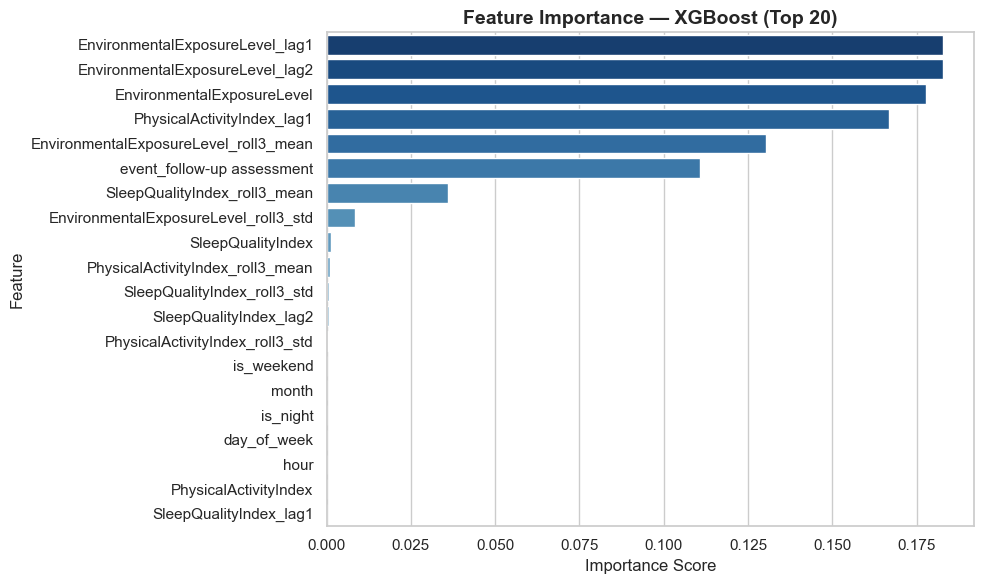

In [11]:
# %% [markdown]
# ## 7. Feature Importance — Best Model

# %%
# Identify best model
best_model_name = summary_df.iloc[0]["Model"]
best_result     = results[best_model_name]
best_model_obj  = best_result["_fitted_model"]

print(f"Best model: {best_model_name}  (F1={summary_df.iloc[0]['F1 Score']:.4f})")

# Re-fit best model on the FULL dataset for production use and importance extraction
best_model_obj.fit(X, y)

# %%
# Extract feature importances (compatible with RF, XGB, LGBM)
if hasattr(best_model_obj, "feature_importances_"):
    importances = best_model_obj.feature_importances_
else:
    raise AttributeError(f"Model {best_model_name} does not expose feature_importances_.")

feat_imp_df = (
    pd.DataFrame({"feature": X.columns, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# Show top 20
top_n = min(20, len(feat_imp_df))
top_features = feat_imp_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    palette="Blues_r",
    ax=ax,
)
ax.set_title(f"Feature Importance — {best_model_name} (Top {top_n})", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.set_ylabel("Feature")
plt.tight_layout()

FIG_IMPORTANCE_PATH = "figures/10_feature_importance.png"
fig.savefig(FIG_IMPORTANCE_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_IMPORTANCE_PATH}")

In [ ]:
# %% [markdown]
# ## 8. Confusion Matrix — Best Model

# %%
# Use aggregated OOF predictions from LOGO evaluation for an unbiased confusion matrix
y_true_agg = best_result["y_true"]
y_pred_agg = best_result["y_pred"]

cm = confusion_matrix(y_true_agg, y_pred_agg)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted: Standard (0)", "Predicted: Preventive (1)"],
    yticklabels=["Actual: Standard (0)",    "Actual: Preventive (1)"],
    linewidths=0.5,
    ax=ax,
)
ax.set_title(
    f"Confusion Matrix — {best_model_name}\n"
    f"(LeaveOneGroupOut OOF predictions)",
    fontsize=13,
    fontweight="bold",
)
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()

FIG_CM_PATH = "figures/11_confusion_matrix.png"
fig.savefig(FIG_CM_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_CM_PATH}")

# Detailed classification report
print(f"\nClassification Report — {best_model_name} (OOF):")
print(classification_report(
    y_true_agg,
    y_pred_agg,
    target_names=["Standard (0)", "Preventive Support (1)"],
    zero_division=0,
))


In [ ]:
# %% [markdown]
# ## 9. Save Best Model

# %%
MODEL_SAVE_PATH = "models/best_model.pkl"

# Package model together with its metadata for traceability
model_artifact = {
    "model":           best_model_obj,
    "model_name":      best_model_name,
    "feature_columns": list(X.columns),
    "f1_score_logo":   float(summary_df.iloc[0]["F1 Score"]),
    "precision_logo":  float(summary_df.iloc[0]["Precision"]),
    "recall_logo":     float(summary_df.iloc[0]["Recall"]),
    "label_mapping":   {0: "standard", 1: "preventive_support"},
    "challenge":       "Reply Sandbox 2026",
    "notebook":        "03_model_training",
}

joblib.dump(model_artifact, MODEL_SAVE_PATH, compress=3)
print(f"Model artifact saved → {MODEL_SAVE_PATH}")

# Quick sanity-check: reload and verify predictions are identical
reloaded     = joblib.load(MODEL_SAVE_PATH)
preds_check  = reloaded["model"].predict(X)
print(f"Reload sanity check passed — predictions shape: {preds_check.shape}")


In [ ]:
# %% [markdown]
# ## 10. Final Summary

# %%
best_f1        = summary_df.iloc[0]["F1 Score"]
best_precision = summary_df.iloc[0]["Precision"]
best_recall    = summary_df.iloc[0]["Recall"]

print("=" * 60)
print("         REPLY SANDBOX 2026 — MODEL TRAINING SUMMARY")
print("=" * 60)
print(f"  Best model        : {best_model_name}")
print(f"  F1 Score  (LOGO)  : {best_f1:.4f}")
print(f"  Precision (LOGO)  : {best_precision:.4f}")
print(f"  Recall    (LOGO)  : {best_recall:.4f}")
print(f"  Saved to          : {MODEL_SAVE_PATH}")
print(f"  Feature importance: {FIG_IMPORTANCE_PATH}")
print(f"  Confusion matrix  : {FIG_CM_PATH}")
print("=" * 60)
print()
print("Model comparison (all):")
print(summary_df.to_string(index=False))
print()
print("Next step → notebook 04_inference.ipynb")